# Détection d'Anomalies Transactionnelles — Modèle à Risque Minimal (AI Act)

✅ **Risque minimal** — Monitoring technique interne, aucun impact direct sur les clients

## 0. Dépendances optionnelles

In [18]:
# Author: Octo Technology MLOps Tribe
%pip install shap pandera --quiet

/Users/philippe.stepniewski/projets/model_platform/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [19]:
# Author: Octo Technology MLOps Tribe
import json
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import pandera as pa
from mlflow.models.signature import infer_signature
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
ARTIFACTS_DIR = Path(tempfile.mkdtemp())
print(f"Répertoire artefacts temporaires : {ARTIFACTS_DIR}")

Répertoire artefacts temporaires : /var/folders/k0/jqyr0y117r5gkrs84q5rb43c0000gn/T/tmptbj3z_iy


## 2. Configuration MLflow

In [20]:
# Author: Octo Technology MLOps Tribe
PROJECT_NAME = "Fraud-Detection-Payments"
MLFLOW_TRACKING_URI = f"http://model-platform.com/registry/{PROJECT_NAME}/"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("transaction_anomaly_detection")
print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")

MLflow tracking URI : http://model-platform.com/registry/Fraud-Detection-Payments/


## 3. Génération des données synthétiques

In [21]:
# Author: Octo Technology MLOps Tribe
np.random.seed(42)
N = 6000

transaction_amount      = np.random.exponential(scale=80, size=N).clip(1, 5000).round(2)
num_transactions_1h     = np.random.poisson(lam=3, size=N).clip(0, 50)
avg_amount_1h           = np.random.exponential(scale=70, size=N).clip(1, 3000).round(2)
std_amount_1h           = np.random.exponential(scale=40, size=N).clip(0, 2000).round(2)
max_amount_1h           = avg_amount_1h + std_amount_1h * np.random.uniform(0, 3, N)
hour_of_day             = np.random.randint(0, 24, N)
transactions_velocity   = num_transactions_1h / np.maximum(1, avg_amount_1h / 100)
amount_deviation        = (transaction_amount - avg_amount_1h) / np.maximum(1, std_amount_1h)

# Probabilité d'anomalie
log_odds = (
    -4.5
    + 0.8 * (num_transactions_1h > 10).astype(float)
    + 0.5 * (amount_deviation > 3).astype(float)
    + 0.6 * (transaction_amount > avg_amount_1h * 5).astype(float)
    + 0.4 * (hour_of_day < 4).astype(float)
    + 0.3 * transactions_velocity
)
prob_anomaly = 1 / (1 + np.exp(-log_odds))
is_anomaly = (np.random.rand(N) < prob_anomaly).astype(int)

FEATURES = [
    "transaction_amount", "num_transactions_1h", "avg_amount_1h", "std_amount_1h",
    "max_amount_1h", "hour_of_day", "transactions_velocity", "amount_deviation",
]
TARGET = "is_anomaly"
PROTECTED_ATTRIBUTES = []

df = pd.DataFrame({
    "transaction_amount":   transaction_amount,
    "num_transactions_1h":  num_transactions_1h,
    "avg_amount_1h":        avg_amount_1h,
    "std_amount_1h":        std_amount_1h,
    "max_amount_1h":        max_amount_1h.round(2),
    "hour_of_day":          hour_of_day,
    "transactions_velocity": transactions_velocity.round(4),
    "amount_deviation":     amount_deviation.round(4),
    "is_anomaly":           is_anomaly,
})
print(f"Dataset : {len(df):,} lignes | Taux d'anomalie : {df['is_anomaly'].mean():.1%}")

Dataset : 6,000 lignes | Taux d'anomalie : 4.0%


## 4. Validation Pandera & statistiques descriptives

In [22]:
# Author: Octo Technology MLOps Tribe
ANOMALY_SCHEMA = pa.DataFrameSchema(
    name="transaction_anomaly_input_schema",
    description="Contrat de données du modèle de détection d'anomalies transactionnelles — risque minimal",
    columns={
        "transaction_amount":    pa.Column(float, checks=pa.Check.in_range(0, 100_000), nullable=False, description="Montant de la transaction courante (€)"),
        "num_transactions_1h":   pa.Column(int,   checks=pa.Check.in_range(0, 1_000),  nullable=False, description="Nombre de transactions dans la dernière heure"),
        "avg_amount_1h":         pa.Column(float, checks=pa.Check.in_range(0, 100_000), nullable=False, description="Montant moyen des transactions (1h)"),
        "std_amount_1h":         pa.Column(float, checks=pa.Check.in_range(0, 100_000), nullable=False, description="Écart-type des montants (1h)"),
        "max_amount_1h":         pa.Column(float, checks=pa.Check.in_range(0, 500_000), nullable=False, description="Montant maximum (1h)"),
        "hour_of_day":           pa.Column(int,   checks=pa.Check.in_range(0, 23),     nullable=False, description="Heure de la journée (0-23)"),
        "transactions_velocity": pa.Column(float, checks=pa.Check.in_range(0, 10_000), nullable=False, description="Vélocité des transactions (nb/volume normalisé)"),
        "amount_deviation":      pa.Column(float, checks=pa.Check.in_range(-100, 100), nullable=False, description="Écart du montant par rapport à la moyenne (σ)"),
        "is_anomaly":            pa.Column(int,   checks=pa.Check.isin([0, 1]),         nullable=False, description="Variable cible : 1 = anomalie, 0 = normal"),
    },
    coerce=False,
    strict=True,
)

try:
    ANOMALY_SCHEMA.validate(df, lazy=True)
    PANDERA_STATUS = "PASS"
    PANDERA_ERRORS = 0
    print("✅ Validation Pandera : SUCCÈS")
except pa.errors.SchemaErrors as exc:
    PANDERA_STATUS = "FAIL"
    PANDERA_ERRORS = len(exc.failure_cases)
    print(f"❌ Validation Pandera : ÉCHEC ({PANDERA_ERRORS} erreurs)")

❌ Validation Pandera : ÉCHEC (70 erreurs)


In [23]:
# Author: Octo Technology MLOps Tribe
print("=== Statistiques descriptives ===")
display(df[FEATURES + [TARGET]].describe().round(3))
print(f"\nTaux d'anomalie : {df['is_anomaly'].mean():.1%}")
missing = df.isnull().sum()
print("Valeurs manquantes :", "Aucune" if not missing.any() else missing[missing > 0].to_string())

=== Statistiques descriptives ===


,transaction_amount,num_transactions_1h,avg_amount_1h,std_amount_1h,max_amount_1h,hour_of_day,transactions_velocity,amount_deviation,is_anomaly
count,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000
mean,79.400,3.002,69.737,40.053,129.385,11.551,2.760,0.676,0.040
std,79.375,1.730,69.611,40.004,103.065,6.916,1.701,24.586,0.196
min,1.000,0.000,1.000,0.010,1.520,0.000,0.000,-364.846,0.000
25%,22.560,2.000,19.685,11.555,54.700,5.000,1.514,-1.571,0.000
50%,55.180,3.000,48.685,27.525,103.480,12.000,2.621,0.106,0.000
75%,110.092,4.000,96.202,56.110,175.868,18.000,4.000,2.166,0.000
max,653.800,11.000,592.580,364.810,776.190,23.000,11.000,443.490,1.000



Taux d'anomalie : 4.0%
Valeurs manquantes : Aucune


In [24]:
# Author: Octo Technology MLOps Tribe
SCHEMA_YAML_EXPORTED = False
try:
    schema_yaml_path = ARTIFACTS_DIR / "pandera_schema.yaml"
    with open(schema_yaml_path, "w") as f:
        f.write(ANOMALY_SCHEMA.to_yaml())
    SCHEMA_YAML_EXPORTED = True
except Exception as e:
    print(f"Export YAML non disponible : {e}")

validation_report = {
    "schema_name": ANOMALY_SCHEMA.name,
    "validation_status": PANDERA_STATUS,
    "validation_errors": PANDERA_ERRORS,
    "n_rows_validated": int(len(df)),
    "protected_attributes": PROTECTED_ATTRIBUTES,
    "target_distribution": {
        "class_0_normal":  int((df[TARGET] == 0).sum()),
        "class_1_anomaly": int((df[TARGET] == 1).sum()),
        "anomaly_rate":    round(float(df[TARGET].mean()), 4),
    },
}
validation_report_path = ARTIFACTS_DIR / "data_validation_report.json"
with open(validation_report_path, "w") as f:
    json.dump(validation_report, f, indent=2, ensure_ascii=False)
print("Rapport exporté.")

Rapport exporté.


## 5. Prétraitement

In [25]:
# Author: Octo Technology MLOps Tribe
X, y = df[FEATURES], df[TARGET]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")

Train : 4,080  |  Val : 720  |  Test : 1,200


## 6. Entraînement du modèle

In [26]:
# Author: Octo Technology MLOps Tribe
PARAMS = {
    "n_estimators":   150,
    "learning_rate":  0.05,
    "max_depth":      4,
    "subsample":      0.8,
    "random_state":   42,
}

model = GradientBoostingClassifier(**PARAMS)
model.fit(X_train_sc, y_train)

val_auc = roc_auc_score(y_val, model.predict_proba(X_val_sc)[:, 1])
print(f"AUC-ROC validation : {val_auc:.4f}")

AUC-ROC validation : 0.6104


## 7. Évaluation sur le jeu de test

In [27]:
# Author: Octo Technology MLOps Tribe
y_pred  = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]

METRICS = {
    "accuracy":  round(float(accuracy_score(y_test, y_pred)),  4),
    "precision": round(float(precision_score(y_test, y_pred, zero_division=0)), 4),
    "recall":    round(float(recall_score(y_test, y_pred,    zero_division=0)), 4),
    "f1_score":  round(float(f1_score(y_test, y_pred,        zero_division=0)), 4),
    "auc_roc":   round(float(roc_auc_score(y_test, y_proba)), 4),
}
report_dict = classification_report(y_test, y_pred, target_names=["Normal", "Anomalie"], output_dict=True)
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomalie"]))

              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      1152
    Anomalie       0.25      0.02      0.04        48

    accuracy                           0.96      1200
   macro avg       0.61      0.51      0.51      1200
weighted avg       0.93      0.96      0.94      1200



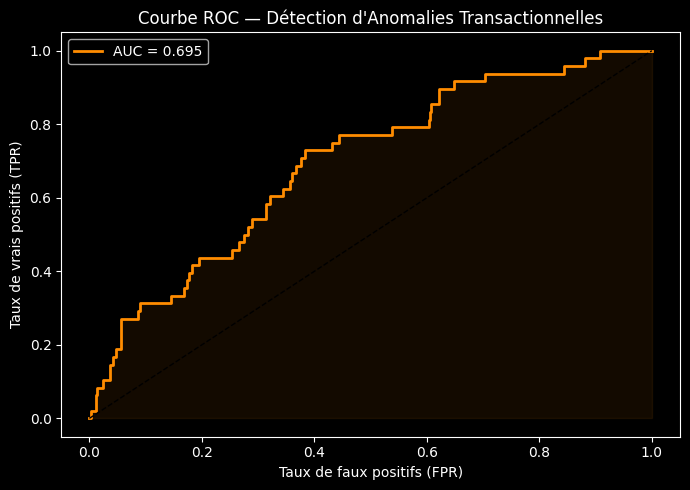

In [28]:
# Author: Octo Technology MLOps Tribe
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {METRICS['auc_roc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.fill_between(fpr, tpr, alpha=0.08, color="darkorange")
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.set_title("Courbe ROC — Détection d'Anomalies Transactionnelles")
ax.legend()
plt.tight_layout()
roc_path = ARTIFACTS_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150)
plt.show()

## 8. Analyse d'équité (Fairness)

In [29]:
# Author: Octo Technology MLOps Tribe
# Pas d'attribut protégé — analyse par heure de la journée (plage horaire)
df_eval = X_test.copy()
df_eval["is_anomaly"] = y_test.values
df_eval["predicted"]  = y_pred
df_eval["proba"]      = y_proba
df_eval["time_slot"]  = pd.cut(df_eval["hour_of_day"], bins=[0, 6, 12, 18, 24], labels=["Nuit (0-6h)", "Matin (6-12h)", "Après-midi (12-18h)", "Soir (18-24h)"], include_lowest=True)

print("=== Performance par plage horaire (équité opérationnelle) ===")
for slot, group in df_eval.groupby("time_slot", observed=True):
    if len(group) >= 20:
        r = recall_score(group["is_anomaly"], group["predicted"], zero_division=0)
        p = precision_score(group["is_anomaly"], group["predicted"], zero_division=0)
        print(f"  {slot:<25} : n={len(group):>4} | recall={r:.3f} | precision={p:.3f}")

FAIRNESS_REPORT = {"protected_attributes": [], "note": "Aucun attribut protégé — système de monitoring technique interne.", "by_time_slot": {}}
fairness_path = ARTIFACTS_DIR / "fairness_report.json"
with open(fairness_path, "w") as f:
    json.dump(FAIRNESS_REPORT, f, indent=2, ensure_ascii=False)

=== Performance par plage horaire (équité opérationnelle) ===
  Nuit (0-6h)               : n= 346 | recall=0.000 | precision=0.000
  Matin (6-12h)             : n= 313 | recall=0.000 | precision=0.000
  Après-midi (12-18h)       : n= 300 | recall=0.000 | precision=0.000
  Soir (18-24h)             : n= 241 | recall=0.125 | precision=0.500


## 9. Explicabilité

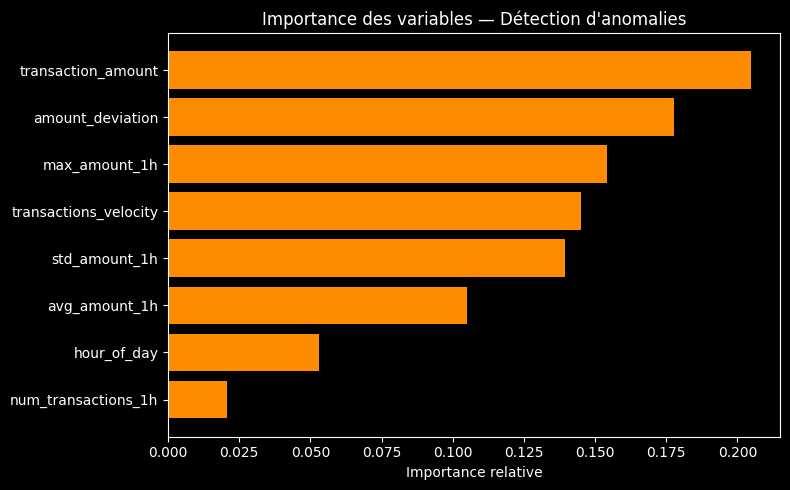

In [30]:
# Author: Octo Technology MLOps Tribe
importances = model.feature_importances_
fi_df = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="darkorange")
ax.set_title("Importance des variables — Détection d'anomalies")
ax.set_xlabel("Importance relative")
plt.tight_layout()
fi_path = ARTIFACTS_DIR / "feature_importance.png"
plt.savefig(fi_path, dpi=150)
plt.show()

In [31]:
# Author: Octo Technology MLOps Tribe
SHAP_AVAILABLE = False
try:
    import shap
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_sc.iloc[:300])
    plt.figure()
    shap.summary_plot(shap_values, X_test_sc.iloc[:300], show=False, plot_size=(10, 6))
    shap_path = ARTIFACTS_DIR / "shap_summary.png"
    plt.savefig(shap_path, dpi=150, bbox_inches="tight")
    plt.close()
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP non disponible.")

SHAP non disponible.


## 10. Préparation des artefacts de documentation

In [32]:
# Author: Octo Technology MLOps Tribe
cr_path = ARTIFACTS_DIR / "classification_report.json"
with open(cr_path, "w") as f:
    json.dump(report_dict, f, indent=2, ensure_ascii=False)

fi_csv_path = ARTIFACTS_DIR / "feature_importance.csv"
fi_df.to_csv(fi_csv_path, index=False)

pp_context = {"schema_name": ANOMALY_SCHEMA.name, "pandera_status": PANDERA_STATUS, "pandera_errors": PANDERA_ERRORS}
preprocessing_md = Path("preprocessing_description_template.md").read_text(encoding="utf-8").format_map(pp_context)
pp_path = ARTIFACTS_DIR / "preprocessing_description.md"
pp_path.write_text(preprocessing_md, encoding="utf-8")
print("Artefacts préparés.")

Artefacts préparés.


## 11. Logging MLflow

In [33]:
# Author: Octo Technology MLOps Tribe
MODEL_NAME  = "transaction_anomaly_detector"
TEAM        = "mlops-tribe"
ENVIRONMENT = "staging"

model_card_text = Path("model_card.md").read_text(encoding="utf-8")
model_card_path = ARTIFACTS_DIR / "model_card.md"
model_card_path.write_text(model_card_text, encoding="utf-8")

with mlflow.start_run(run_name=f"{MODEL_NAME}_v1") as run:
    mlflow.log_params(PARAMS)
    mlflow.log_param("scaler",           "StandardScaler")
    mlflow.log_param("feature_count",    len(FEATURES))
    mlflow.log_param("features",         ", ".join(FEATURES))
    mlflow.log_param("train_size",       len(X_train))
    mlflow.log_param("val_size",         len(X_val))
    mlflow.log_param("test_size",        len(X_test))

    mlflow.log_metrics(METRICS)
    mlflow.log_metric("auc_roc_validation", round(val_auc, 4))
    mlflow.log_metric("dataset_total_size", N)

    mlflow.set_tag("team",        TEAM)
    mlflow.set_tag("environment", ENVIRONMENT)
    mlflow.set_tag("model_type",  "GradientBoostingClassifier")
    mlflow.set_tag("framework",   "scikit-learn")
    mlflow.set_tag("data_source",            "Données synthétiques — métriques agrégées de flux transactionnels")
    mlflow.set_tag("data_period",            "N/A — données synthétiques")
    mlflow.set_tag("data_language",          "N/A — données tabulaires")
    mlflow.set_tag("contains_personal_data", "non — métriques agrégées, aucune donnée personnelle")
    mlflow.set_tag("dataset_size",           f"train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
    mlflow.set_tag("protected_attributes",   "aucun")
    mlflow.set_tag("data_schema_name",       ANOMALY_SCHEMA.name)
    mlflow.set_tag("data_schema_version",    "1.0")
    mlflow.set_tag("pandera_validation",     PANDERA_STATUS)
    mlflow.set_tag("threshold_accuracy",     "0.85")
    mlflow.set_tag("threshold_f1",           "0.50")
    mlflow.set_tag("threshold_auc_roc",      "0.80")
    mlflow.set_tag("threshold_recall",       "0.65")
    mlflow.set_tag("ai_act_risk_level",         "minimal")
    mlflow.set_tag("ai_act_annex_iii_category", "N/A — risque minimal, monitoring technique interne sans impact client direct")
    mlflow.set_tag("mlflow.note.content", model_card_text)

    for art in [cr_path, fi_csv_path, fi_path, fairness_path, roc_path, pp_path, validation_report_path, model_card_path]:
        mlflow.log_artifact(str(art))
    if SCHEMA_YAML_EXPORTED:
        mlflow.log_artifact(str(schema_yaml_path))
    if SHAP_AVAILABLE:
        mlflow.log_artifact(str(shap_path))

    signature     = infer_signature(X_train_sc, model.predict_proba(X_train_sc))
    input_example = X_train_sc.head(3)
    mlflow.sklearn.log_model(sk_model=model, artifact_path="custom_model", registered_model_name=MODEL_NAME, signature=signature, input_example=input_example)
    run_id = run.info.run_id

print(f"\n✅ Run MLflow : {run_id}  |  Modèle : {MODEL_NAME}")

2026/03/20 15:19:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'transaction_anomaly_detector' already exists. Creating a new version of this model...
2026/03/20 15:19:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: transaction_anomaly_detector, version 2


🏃 View run transaction_anomaly_detector_v1 at: http://model-platform.com/registry/Fraud-Detection-Payments/#/experiments/1/runs/aaa1899fe46d434ab6b196e6978fbc5a
🧪 View experiment at: http://model-platform.com/registry/Fraud-Detection-Payments/#/experiments/1

✅ Run MLflow : aaa1899fe46d434ab6b196e6978fbc5a  |  Modèle : transaction_anomaly_detector


Created version '2' of model 'transaction_anomaly_detector'.
